# **Project Title:**

**"Retail Sales Insights: A Data Analysis and Visualization Project Using Python"**

---

### **Key Technical Learning Objectives (Student-Friendly):**

1. **Understand and Apply Data Analysis Libraries**
   Learn to use Python libraries like **Pandas**, **NumPy**, **Matplotlib**, and **Seaborn** to manipulate and visualize data.

2. **Work with Real-World Retail Data**
   Load, clean, and analyze a retail sales dataset similar to what businesses use.

3. **Perform Exploratory Data Analysis (EDA)**
   Generate summaries like revenue, profit, and trends using **groupby**, **aggregations**, and **date-based analysis**.

4. **Build Visual Dashboards with Python**
   Create charts such as **line plots**, **bar charts**, and **heatmaps** to find hidden patterns and trends in the data.

5. **Apply Rolling Averages for Trend Forecasting**
   Use techniques like **3-month moving averages** to smooth out fluctuations and interpret long-term trends.

6. **Segment Performance Analysis**
   Analyze customer segments (e.g., Regular, Loyal) to make business decisions using segment-wise revenue and profit.

7. **Data-Driven Storytelling**
   Turn charts and summaries into meaningful business insights and actionable recommendations.

### Import Libraries

---

### `import pandas as pd`

"We are bringing in the **pandas** library and giving it a short name, `pd`.
Pandas helps us **work with tabular data** (like Excel tables), which is what we’ll be using most of the time in data analysis."

Example: We can use pandas to read CSV files, clean up data, and explore it.

---

### `import numpy as np`

"Next, we are bringing in the **numpy** library, using the name `np`.
Numpy gives us tools to **work with numbers and arrays** more efficiently — especially when we need to do mathematical operations."

Example: It helps us calculate averages, standard deviations, etc., very fast.

---

### `import matplotlib.pyplot as plt`

"This line imports the **pyplot module from matplotlib** and calls it `plt`.
This is one of the most common tools used for **creating graphs and charts** in Python."

Example: We’ll use this to draw bar charts, line graphs, etc., to visualize our data.

---

### `import seaborn as sns`

"This one is importing **Seaborn**, another library for data visualization. We give it the nickname `sns`.
Seaborn is built on top of matplotlib and makes our charts look **cleaner and more professional** with less effort."

Example: You can quickly make heatmaps, box plots, and other fancy charts.

---

### `pd.set_option('display.max_columns', None)`

"This is a pandas setting. By default, if a dataset has **many columns**, pandas only shows some of them when we print.
This line **tells pandas to show *all* columns** when we display a DataFrame."

Why is this helpful?
> So we don’t miss any important column when we’re exploring or debugging our data.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)


### Load Data

---

### `df = pd.read_csv("retail_sales.csv", parse_dates=["Date"])`

* `pd.read_csv(...)` means we are **reading a CSV file** using pandas.
* The CSV file is stored online at the link provided. It contains retail sales data.
* `parse_dates=["Date"]` tells pandas to **treat the "Date" column as actual dates**, not just plain text.

Why is this important?
> Because if "Date" is treated like text, we can't do things like sorting by date or extracting month/year from it easily.

After this line, all the data from the file will be stored in a variable called `df`, which stands for **DataFrame** — pandas’ table-like data structure.

---

### `df["Month"] = df["Date"].dt.to_period("M")`

Now we're creating a **new column called "Month"** in the table.

* `df["Date"]` gets the column with the date values.
* `.dt.to_period("M")` converts each full date (like 2023-01-15) into just the **month** (like 2023-01).

Why do this?
> So we can group data by month and do monthly analysis (like total sales per month).

---

### `df["Year"] = df["Date"].dt.year`

Again, we are making a new column called `"Year"`.

* This extracts just the **year part** (like 2023) from each date.
* It helps when we want to group or filter data by year — very useful in time-based business reporting.

---

### `df.head()`

This is a very handy function!

* It **displays the first 5 rows** of our DataFrame.
* Helps us quickly **check if the data looks okay** and if our new columns ("Month" and "Year") were added properly.

Think of it like a preview or "peek" into the data before we go deeper.


In [4]:
df = pd.read_csv("https://samatrix-data.s3.ap-south-1.amazonaws.com/Statistics-Project/retail_sales.csv",
                 parse_dates=["Date"])
df["Month"] = df["Date"].dt.to_period("M")
df["Year"] = df["Date"].dt.year
df.head()

,Date,Region,Category,Product,SalesChannel,PaymentMethod,Quantity,UnitPrice,CostPrice,Discount,Segment,Month,Year
0,2022-04-13,East,Electronics,Smartphone,Online,Debit Card,20,1901.92,1558.81,0.15,Loyal,2022-04,2022
1,2023-09-07,North,Clothing,T-Shirt,Wholesale,UPI,26,320.43,197.84,0.22,New,2023-09,2023
2,2022-04-10,North,Electronics,Smartphone,Online,Debit Card,8,1419.06,860.20,0.24,Regular,2022-04,2022
3,2023-05-07,South,Sports,Football,Wholesale,Cash,6,11.55,10.37,0.15,Loyal,2023-05,2023
4,2022-11-10,West,Books,Non-Fiction,Wholesale,Net Banking,22,24.06,14.60,0.13,Loyal,2022-11,2022


### Data Cleaning

---

### `print(df.isnull().sum())`

🧠 Let’s break this one down:

* `df.isnull()` checks every cell in the DataFrame to see if it has a **missing value** (`NaN` — Not a Number).

  * It returns a DataFrame of `True` and `False` values.
* `.sum()` adds up how many `True` (i.e., missing values) are there **in each column**.

So, this line tells us:
> “How many missing values are there in each column?”

This is very useful before analysis, because missing data can affect results. If we find many missing values, we might decide to clean or fix the data first.

---

### `print(df.describe(include="all"))`

* `df.describe()` gives us a **summary of statistics** for all columns.
* By default, it shows stats like:

  * Count (how many values)
  * Mean
  * Standard deviation (spread)
  * Min
  * Max
  * Percentiles (25%, 50%, 75%)

What does `include="all"` do?

* Normally, `describe()` shows stats only for **numerical columns**.
* `include="all"` tells pandas:

  > “Show me basic stats for **all types of columns**, not just numbers — including text (categorical) columns too.”

So we get useful info like:

* Most frequent category (for text columns),
* Number of unique values,
* etc.

In [5]:
print("Missing values check:")
print(df.isnull().sum())

print("\n Basic info:")
print(df.describe(include="all"))

Missing values check:
Date             0
Region           0
Category         0
Product          0
SalesChannel     0
PaymentMethod    0
Quantity         0
UnitPrice        0
CostPrice        0
Discount         0
Segment          0
Month            0
Year             0
dtype: int64

 Basic info:
                              Date Region     Category Product  SalesChannel  \
count                         2000   2000         2000    2000          2000   
unique                         NaN      4            5      20             3   
top                            NaN   West  Electronics  Laptop  Retail Store   
freq                           NaN    518          422     118           675   
mean    2022-12-29 09:30:57.600000    NaN          NaN     NaN           NaN   
min            2022-01-01 00:00:00    NaN          NaN     NaN           NaN   
25%            2022-06-22 18:00:00    NaN          NaN     NaN           NaN   
50%            2022-12-24 00:00:00    NaN          NaN     NaN  

### Data Cleaning and New Columns

---

### `df['Revenue'] = df['Quantity'] * df['UnitPrice']`

What we are doing here is **creating a new column** in our DataFrame called `Revenue`.

* `df['Quantity']`: This column stores how many units of a product were sold.
* `df['UnitPrice']`: This tells us the price of one unit.


  > So if someone bought 10 T-shirts and each T-shirt costs ₹500, the revenue is:

```
10 * 500 = 5000
```

That’s exactly what this line is doing — multiplying Quantity × Unit Price — and storing the result in a new column called `Revenue`.

---

### `df['Cost'] = df['Quantity'] * df['CostPrice']`

Similar to the previous line, now we’re calculating the **total cost** of the items sold.

* `df['CostPrice']` means the amount **we paid** for one unit (not what we sold it for).
* Again, we multiply it with Quantity to find **our total cost**.

  > So if we sold 10 items and each cost us ₹300, total cost is:

```
10 * 300 = 3000
```

We save this new information in a column named `Cost`.

---

#### `df['Profit'] = df['Revenue'] - df['Cost']`

We now want to find out how much **profit** we made per row (per transaction).

* Revenue is how much we earned.
* Cost is how much we spent.
* Subtract Cost from Revenue → we get Profit.

For example:

```
Revenue = 5000
Cost    = 3000
Profit  = 5000 - 3000 = 2000
```

So this line stores the profit in a column named `Profit`.

---

#### `df.head()`


* `df.head()` just shows the **first 5 rows** of the updated DataFrame.

This is a quick way to check:

> “Did our new columns (Revenue, Cost, Profit) get calculated correctly?”

In [6]:
# Data cleaning and new columns
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df['Cost'] = df['Quantity'] * df['CostPrice']
df['Profit'] = df['Revenue'] - df['Cost']
df.head()

,Date,Region,Category,Product,SalesChannel,PaymentMethod,Quantity,UnitPrice,CostPrice,Discount,Segment,Month,Year,Revenue,Cost,Profit
0,2022-04-13,East,Electronics,Smartphone,Online,Debit Card,20,1901.92,1558.81,0.15,Loyal,2022-04,2022,38038.40,31176.20,6862.20
1,2023-09-07,North,Clothing,T-Shirt,Wholesale,UPI,26,320.43,197.84,0.22,New,2023-09,2023,8331.18,5143.84,3187.34
2,2022-04-10,North,Electronics,Smartphone,Online,Debit Card,8,1419.06,860.20,0.24,Regular,2022-04,2022,11352.48,6881.60,4470.88
3,2023-05-07,South,Sports,Football,Wholesale,Cash,6,11.55,10.37,0.15,Loyal,2023-05,2023,69.30,62.22,7.08
4,2022-11-10,West,Books,Non-Fiction,Wholesale,Net Banking,22,24.06,14.60,0.13,Loyal,2022-11,2022,529.32,321.20,208.12


### **Analyze and visualize trends** in Revenue and Profit **month-by-month**.

---

```python
monthly_trend = df.groupby("Month")[["Revenue", "Profit"]].sum().reset_index()
```

* `df.groupby("Month")`: We are **grouping all the rows** of data based on the **Month** column.
* `[["Revenue", "Profit"]]`: From each month's group, we want to look at only **Revenue** and **Profit** columns.
* `.sum()`: We calculate the **total Revenue and Profit** for each month.
* `.reset_index()`: This makes sure "Month" becomes a regular column again (not an index), which is easier for plotting.

Example:
  > If we had 10 transactions in January, we now get **one row** with the total Revenue and total Profit for January.

---

```python
monthly_trend["Month"] = monthly_trend["Month"].astype(str)
```

* We are converting the Month column to **string format**.
* This helps make sure that when we plot the months on the x-axis, they appear properly as labels (like “2024-01”, “2024-02”…).

---

```python
plt.figure(figsize=(12,6))
```

* We are creating a new **blank plot** (a canvas).
* `figsize=(12,6)` means the width will be 12 inches, height will be 6 inches — a good size for presentations.

---

```python
plt.plot(monthly_trend["Month"], monthly_trend["Revenue"], label="Revenue", marker='o')
plt.plot(monthly_trend["Month"], monthly_trend["Profit"], label="Profit", marker='o')
```

These two lines draw **two line charts**:

* One line for **monthly Revenue**.
* One line for **monthly Profit**.
* `marker='o'` means each point on the line will be marked with a small circle — easier to see data values.

---

```python
plt.xticks(rotation=45)
```

* This **rotates the month names** on the x-axis by 45 degrees so they don’t overlap — great for readability.

---

```python
plt.title("Monthly Revenue and Profit Trends")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.grid()
```

These lines are about making the chart clear and professional:

* Add a title on top.
* Label the x-axis and y-axis.
* Add a grid in the background for easier reading of values.

---

```python
plt.legend()
```

* This adds a **legend** in the corner of the chart so we know which line is Revenue and which is Profit.

---

```python
plt.tight_layout()
```

* This ensures all parts of the chart **fit well** inside the display area — no cutting off of labels or titles.

---

```python
plt.show()
```

* Finally, this **displays the chart** to the screen.


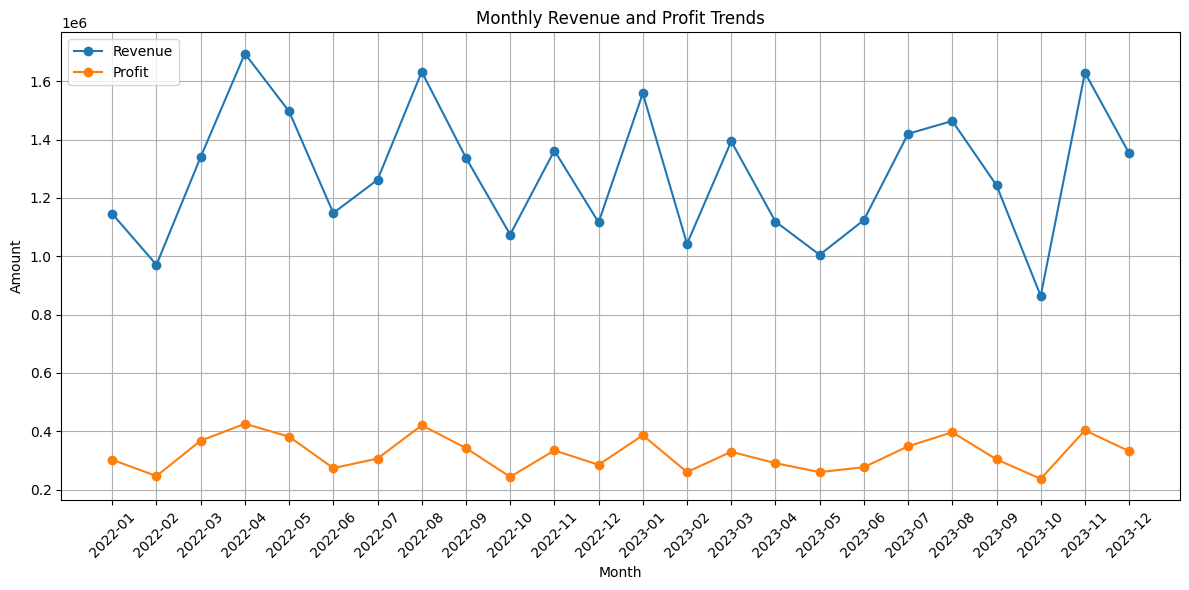

In [8]:
monthly_trend = df.groupby("Month")[["Revenue", "Profit"]].sum().reset_index()
monthly_trend["Month"] = monthly_trend["Month"].astype(str)

plt.figure(figsize=(12,6))
plt.plot(monthly_trend["Month"], monthly_trend["Revenue"], label="Revenue", marker='o')
plt.plot(monthly_trend["Month"], monthly_trend["Profit"], label="Profit", marker='o')
plt.xticks(rotation=45)
plt.title("Monthly Revenue and Profit Trends")
plt.xlabel("Month")
plt.ylabel("Amount")
plt.grid()
plt.legend()
plt.tight_layout()
plt.show()

### Interpretation of **Monthly Revenue and Profit Trends**

---

#### What the Chart Shows:

* Two lines:

  * **Revenue** (in blue)
  * **Profit** (in orange)
* X-axis: Month (from Jan 2022 to Dec 2023)
* Y-axis: Amount (in large numbers, likely in rupees or dollars)
* Each point = total revenue/profit for that month

---

#### Observations

1. **Seasonal Trends:**

   * Revenue peaks are **recurring in April, August, and November** in both 2022 and 2023.
   * These months may correspond to **festival seasons or end-of-quarter sales**, which means higher customer demand.

2. **Profit Follows Revenue — But Not Proportionally:**

   * Profit increases when revenue increases, but not always by the same margin.
   * In some high-revenue months (e.g., April 2022 or November 2023), profit remains moderate — this could mean **heavy discounts or high costs**.

3. **Dip in Revenue and Profit:**

   * There are noticeable dips in **February 2022**, **October 2023**, and **May 2023**.
   * This could reflect off-season periods, **inventory issues**, or **reduced marketing efforts**.

4. **Profit is More Stable than Revenue:**

   * The profit line is flatter and more consistent, even when revenue jumps around.
   * This may indicate **cost control is working**, or **fixed-margin pricing** is in place.

---

#### Actionable Insights for Business

| Observation                                       | Actionable Insight                                                                                   |
| ------------------------------------------------- | ---------------------------------------------------------------------------------------------------- |
| April, August, and November see high revenue   | Plan **targeted campaigns or product launches** around these high-performing months               |
| Dip in October 2023 despite good prior trends  | Investigate what happened — **stockouts, marketing gaps, or operational issues**                  |
| Profit doesn’t increase as much as revenue     | Review **discount strategy or supplier pricing** — is revenue being bought at the cost of margin? |
| Consistent profit despite revenue fluctuations | Shows **good cost management** — continue or enhance current budgeting controls                    |
| Recurring revenue cycles                       | Use insights to **build seasonal sales calendar** with optimized inventory and staffing           |

---

### **Analyze and visualize revenue by product category**.

This chart helps businesses quickly answer questions like:

* Which product category is performing the best?
* Which one needs attention or promotion?

---

#### `def plot_cat_rev():`

This line defines a **function** called `plot_cat_rev`.

* `def` stands for **define a function**.
* `plot_cat_rev` is just the name we chose — short for "plot category revenue".
* The **colon (`:`)** means the next indented lines will be part of this function.

Think of this as building a small machine. You press a button (call the function), and it will generate a chart of revenue by category.

---

#### `cat_rev = df.groupby("Category")["Revenue"].sum().sort_values()`

This line does all the data preparation. Let’s break it down:

1. `df.groupby("Category")`:

   * Group the data by the **Category** column (like Electronics, Fashion, etc.).
   * All rows with the same category are grouped together.

2. `["Revenue"]`:

   * From each group, we only want the **Revenue** column.

3. `.sum()`:

   * Add up all the revenue **within each category**.

4. `.sort_values()`:

   * Sort the categories by total revenue, from **lowest to highest** (so small bars come first on the chart).

This gives us a clean table of **total revenue for each category**, sorted in ascending order.

---

#### `cat_rev.plot(kind='barh', figsize=(10,5), color='skyblue')`

Here we are telling Python to **draw a horizontal bar chart**:

* `kind='barh'` → “bar horizontal”
* `figsize=(10, 5)` → The chart will be 10 inches wide and 5 inches tall
* `color='skyblue'` → The bars will appear in a sky blue color

This line actually **draws the chart** — the x-axis will show revenue, and the y-axis will list the categories.

---

#### `plot_cat_rev()`

This final line is where we **call the function** we just defined.

Think of it like saying:

> “Okay, now run the machine we built and show me the chart.”

---

#### Output:

A clean, simple **horizontal bar chart** showing which product categories bring in the most revenue — and which ones bring in the least.

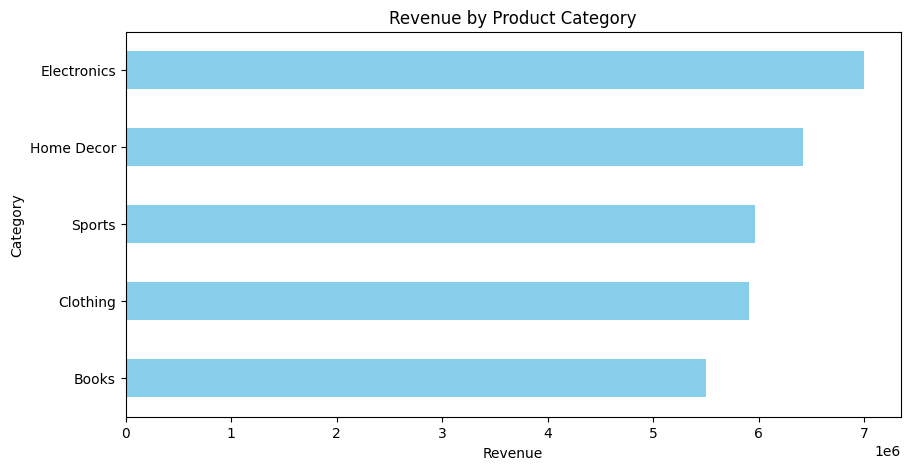

In [12]:
def plot_cat_rev():
    cat_rev = df.groupby("Category")["Revenue"].sum().sort_values()
    cat_rev.plot(kind='barh', figsize=(10,5), color='skyblue')
    plt.title("Revenue by Product Category")
    plt.xlabel("Revenue")
    plt.show()
    plt.show(block=False)
    plt.pause(0.001)

plot_cat_rev()

### Interpret the **"Revenue by Product Category"** horizontal bar chart

---

##### What the Chart Shows:

* The chart compares **total revenue** across five product categories:

  * Electronics
  * Home Decor
  * Sports
  * Clothing
  * Books

* Each bar represents **total revenue** earned from each category.

* The longer the bar → the more money that category earned.

---

#### Observations:

1. **Electronics is the Top Performer**

   * Clearly the highest revenue generator.
   * Likely high-ticket items like laptops and smartphones are driving sales.

2. **Books is the Lowest Revenue Contributor**

   * Even though books might sell frequently, the **unit price is low**, so revenue is lower.

3. **Home Decor, Sports, and Clothing are Mid-Range**

   * These three categories are close to each other in revenue, suggesting similar market interest or pricing.

---

#### Actionable Business Insights

| Observation                                                | Actionable Insight                                                                                                        |
| ---------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------- |
| **Electronics performs best**                           | Double down on this category — increase marketing, expand product range, and stock key items during peak seasons.       |
| **Books generate least revenue**                        | Reassess this category — consider bundling offers, targeting niche readers, or reducing shelf space.                    |
| **Mid-performing categories (Clothing, Sports, Decor)** | Consider focused campaigns: seasonal fashion sales, sports promotions during events, or decor bundles during holidays. |
| **Diverse revenue distribution**                        | Maintain a good mix in inventory — don’t rely only on one product line. Try to push second-tier categories upward.     |

---

### Analyze **how different sales channels (like Online, Retail Store, etc.) are performing** in terms of revenue and profit.

This helps us compare how different **channels** are doing in business:

* Is the **online store** bringing in more money than physical stores?
* Is **wholesale** giving us less revenue but better profit margins?

---

#### `def plot_channel_perf():`

This line defines a **function** named `plot_channel_perf`.

* `def` is the keyword in Python used to **define a new function**.
* `plot_channel_perf` is just a name we chose — it stands for “plot channel performance”.
* The colon `:` means the next indented block belongs to this function.

This function won’t run until we call it. We are just building the “machine” for now.

---

#### `channel_perf = df.groupby("SalesChannel")[["Revenue", "Profit"]].sum().sort_values("Revenue")`

This line does all the **data preparation**. Let’s walk through it step by step:

#### Step 1: `df.groupby("SalesChannel")`

* This groups the entire dataset by the **SalesChannel** column (like "Online", "Retail Store", "Wholesale").
* It’s like separating all the data into buckets — one bucket per sales channel.

#### Step 2: `[["Revenue", "Profit"]]`

* We are telling Python:

  > “From each group, just focus on the **Revenue** and **Profit** columns.”

#### Step 3: `.sum()`

* Add up all the Revenue and Profit **for each channel**.
* So for example:

  * "Online" channel may have ₹3 million revenue and ₹500,000 profit.
  * "Retail Store" may have ₹5 million revenue and ₹700,000 profit.

#### Step 4: `.sort_values("Revenue")`

* This sorts the results **from lowest to highest revenue**, so that the smallest bar appears at the bottom of the chart.

---

#### `channel_perf.plot(kind="bar", figsize=(8,5))`

Now we’re making the chart.

* `.plot(...)` creates the actual **bar chart**.
* `kind="bar"` means it will be a **vertical bar chart**.
* `figsize=(8, 5)` sets the width and height of the chart in inches.

The X-axis will show each **Sales Channel**.
The Y-axis will show both **Revenue** and **Profit**, using two bars per channel.

---

#### `plot_channel_perf()`

* This is where we **call the function**.
* Think of it like pressing the "Start" button on the machine we built above.
* This line actually **runs all the steps inside the function** and displays the bar chart.

---

#### Expected Output:

A **bar chart** showing:

* Total **Revenue** and **Profit** for each **Sales Channel** (e.g., Online, Retail Store, Wholesale).
* Sorted from lowest to highest by Revenue.

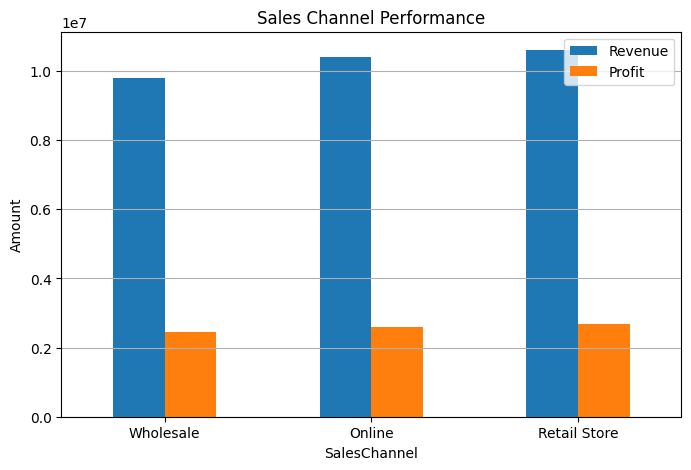

In [13]:
# Sales Channel Performance
def plot_channel_perf():
    channel_perf = df.groupby("SalesChannel")[["Revenue", "Profit"]].sum().sort_values("Revenue")
    channel_perf.plot(kind="bar", figsize=(8,5))
    plt.title("Sales Channel Performance")
    plt.ylabel("Amount")
    plt.xticks(rotation=0)
    plt.grid(axis="y")
    plt.show()
    plt.show(block=False)
    plt.pause(0.001)

plot_channel_perf()

#### Interpret the bar chart - **“Sales Channel Performance”**

---

* Three **Sales Channels**:

  * Online
  * Retail Store
  * Wholesale

* Two bars per channel:

  * **Blue** bar = Total **Revenue** generated
  * **Orange** bar = Total **Profit** earned

---

#### Key Observations:

1. **Retail Store is the Highest Revenue Generator**

   * The tallest blue bar belongs to Retail Store.
   * It brings in the most money overall.

2. **Profit Across Channels is Close**

   * Orange bars (Profit) are similar for all three channels — no drastic difference.
   * Even though revenue differs, the **profit margins** may be consistent or well-balanced.

3. **Wholesale Has Lowest Revenue, But Profit Is Not Much Lower**

   * Wholesale earns the **least revenue**, but its profit isn’t that far behind.
   * This could mean that wholesale has **lower costs or higher efficiency**.

4. **Online Sits in the Middle**

   * Performs well in both revenue and profit.
   * Possibly **stable and consistent** channel.

---

#### Actionable Insights for Business:

| Insight                                    | Suggested Action                                                                                 |
| ------------------------------------------ | ------------------------------------------------------------------------------------------------ |
| Retail Store brings in highest revenue  | Consider expanding store locations, hiring more staff, or increasing inventory there           |
| Profits are similar across all channels | Review cost structures — are we getting better margins in Wholesale?                          |
| Wholesale makes the least revenue       | Investigate product range or customer demand in this channel                                   |
| Online performs steadily               | Use this as a backbone — invest in marketing campaigns, improve website UX, or boost ad spend |
| Balanced profit suggests efficient ops  | Maintain cost discipline — possibly replicate Wholesale model in other areas                  |

---

### Plot Category Revenue

* Which product categories are earning the most money
* Which ones might need help or promotion

---

#### `def plot_cat_rev():`

* `def` means **define** — we are building a small block of reusable code.
* `plot_cat_rev` is the name of the function. It’s short for “plot category revenue”.
* The `():` means this function doesn’t need any input from us right now, and the colon tells Python “the function starts here.”

---

#### `cat_rev = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)`

Let’s unpack this big line carefully:

#### `df.groupby('Category')`

* This says: “Take all the data and **group it by the Category column**.”
* So if we have categories like `"Electronics"`, `"Books"`, `"Clothing"` — we’re grouping all rows of the same type together.

#### `['Revenue']`

* From each category group, we only want to look at the **Revenue** column.

#### `.sum()`

* Now, we’re **adding up** all the revenue values **within each category**.
* So we get total revenue **per category**.

#### `.sort_values(ascending=False)`

* This sorts the categories from **highest revenue to lowest**.
* `ascending=False` means “biggest at the top.”

At the end of this line, `cat_rev` holds a list of categories and their total revenues, sorted from highest to lowest.

---

#### `cat_rev.plot(kind='bar', figsize=(10,5), color='skyblue')`

This is the line that actually **draws the chart**.

* `.plot(...)` tells Python: “Let’s visualize the data.”
* `kind='bar'` means it’s a **vertical bar chart**.
* `figsize=(10,5)` means the chart will be 10 inches wide and 5 inches tall.
* `color='skyblue'` gives it a nice soft color for the bars.

Each bar represents one product category. The taller the bar, the more money that category made.

---

#### `plot_cat_rev()`

This is the moment we **run the function**.

* We’ve built the machine above. This line is like pressing the **"Start" button**.
* It runs all the steps: group, sum, sort, plot — and finally **shows the chart**.

---

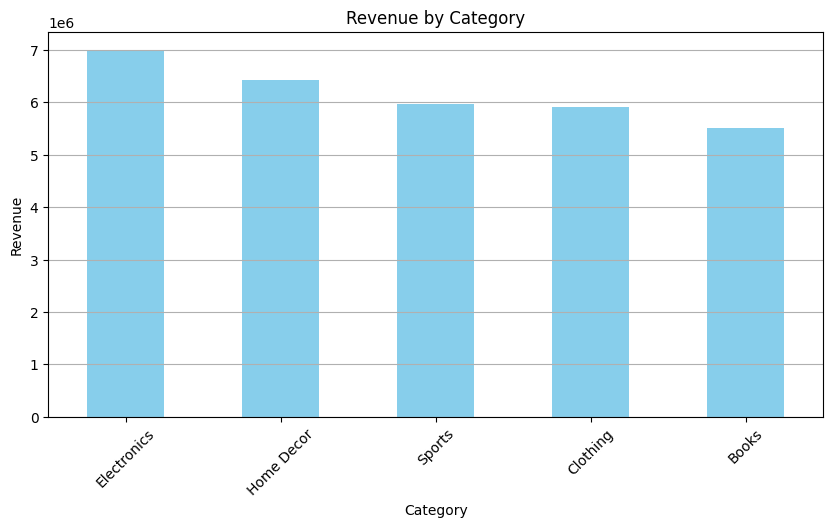

In [14]:
# Revenue by Category
def plot_cat_rev():
    cat_rev = df.groupby('Category')['Revenue'].sum().sort_values(ascending=False)
    cat_rev.plot(kind='bar', figsize=(10,5), color='skyblue')
    plt.title('Revenue by Category')
    plt.ylabel('Revenue')
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.show()
    plt.show(block=False)
    plt.pause(0.001)

plot_cat_rev()

### Interpret the chart - **"Revenue by Category"**

---

* **X-axis**: Product categories
  (Electronics, Home Decor, Sports, Clothing, Books)

* **Y-axis**: Total revenue generated by each category

* Bars are in **descending order** from highest to lowest revenue

* All bars are in the same sky-blue color for consistent comparison

---

#### Key Observations:

1. **Electronics leads the pack**

   * It is the **top revenue-generating category**.
   * Possibly due to higher unit prices (e.g., phones, laptops).

2. **Home Decor is strong**

   * Second-highest in revenue — shows strong interest or seasonal popularity.
   * May include higher-margin or trending products.

3. **Sports, Clothing, and Books are close**

   * These three categories form the lower half of the chart.
   * Their revenues are not far apart, suggesting **similar popularity or pricing**.
   * Books bring the least revenue among all.

---

#### Actionable Business Insights

| Observation                               | Suggested Action                                                                                                 |
| ----------------------------------------- | ---------------------------------------------------------------------------------------------------------------- |
| Electronics performs best              | Invest in expanding product variety and marketing for Electronics. Stock popular models or bundle accessories. |
| Home Decor is promising                | Consider seasonal promotions (Diwali, New Year) and influencer marketing in this category.                    |
| Books earn the least                   | Explore bundling (e.g., book sets), loyalty rewards, or partnerships with authors to improve sales.            |
| Close gap between mid-range categories | Run A/B campaigns or discounts in Clothing and Sports to test what improves engagement and conversions.       |
| No extreme underperformer              | Business is **diversified**, but improvement can be driven by focusing on **category-specific campaigns**.     |

---

### **Find the top 5 most profitable products**

* We can see which products are making the most profit.
* Helps in **product planning, stocking decisions, and marketing focus**.
* Focus on promoting these top performers to increase overall profitability.

---

#### `def plot_top_products():`

This line is where we **define a function** named `plot_top_products`.

* `def` tells Python we are creating a new function.
* `plot_top_products` is just a name we chose — it stands for "plot the top products".
* The parentheses `()` mean we don’t need to give the function any input right now.
* The colon `:` marks the start of the function block.

Think of this like building a small machine — we’re setting up all the instructions inside the function, and we’ll run it later.

---

#### `top_products = df.groupby('Product')['Profit'].sum().sort_values(ascending=False).head(5)`

Let’s break this down piece by piece:

#### `df.groupby('Product')`

* This groups all the rows in the DataFrame by the **Product** column.
* Example: All rows with "Laptop" are grouped together, all rows with "Shoes" are grouped together, and so on.

#### `['Profit']`

* From each group (each product), we are only focusing on the **Profit** column.

#### `.sum()`

* We are adding up all the profit values **for each product**.
* Now we know how much total profit each product has made.

#### `.sort_values(ascending=False)`

* We sort the products from **highest to lowest total profit**.

#### `.head(5)`

* We only want the **top 5 products** with the highest total profit.

At the end of this line, `top_products` holds a small table:
5 products (the most profitable ones) and their total profit values.

---

#### `sns.barplot(x=top_products.values, y=top_products.index)`

This line **draws the bar chart** using Seaborn (`sns`):

* `x=top_products.values`: On the X-axis, we put the profit numbers.
* `y=top_products.index`: On the Y-axis, we put the product names.

This creates a **horizontal bar plot** where:

* The longest bar = the product with the most profit
* Shorter bars = slightly less profitable products

---

#### `plot_top_products()`

This is where we **run the function** — it’s like pressing “Start” on the machine we built above.

* It will group the data, pick the top 5 profitable products, and draw the chart.


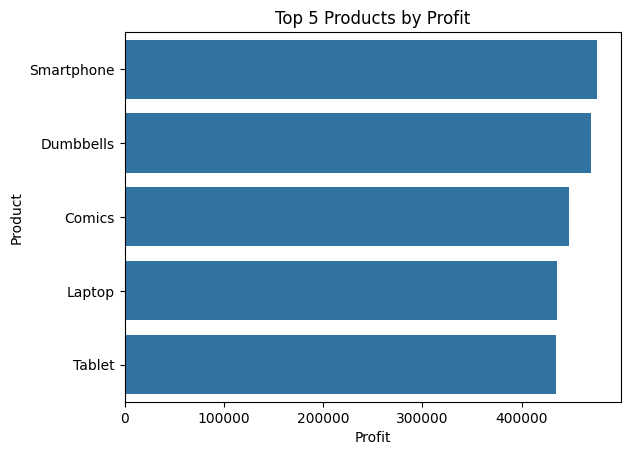

In [15]:
# 🔍 Top 5 Products by Profit
def plot_top_products():
    top_products = df.groupby('Product')['Profit'].sum().sort_values(ascending=False).head(5)
    sns.barplot(x=top_products.values, y=top_products.index)
    plt.title('Top 5 Products by Profit')
    plt.xlabel('Profit')
    plt.show()
    plt.show(block=False)
    plt.pause(0.001)

plot_top_products()

### Insights from the bar chart - **"Top 5 Products by Profit"**

---

* The chart displays the **top 5 individual products** that have generated the **highest profit**.
* The X-axis shows the **total profit value**.
* The Y-axis lists the product names.
* Bars are arranged **from highest to lower profit** in descending order.

### Top 5 Profitable Products:

1. **Smartphone**
2. **Dumbbells**
3. **Comics**
4. **Laptop**
5. **Tablet**

---

#### Observations:

1. **Smartphones are the most profitable product**

   * Indicates high volume of sales, high margins, or both.
   * Likely a best-seller and/or premium-priced item.

2. **Fitness products like Dumbbells are strong performers**

   * Could be a result of health trends, seasonal spikes (e.g., New Year), or targeted campaigns.
   * Suggests opportunity to expand the fitness segment.

3. **Comics, Tablets, and Laptops are also profitable**

   * Tablets and Laptops are common tech essentials with good price points.
   * Comics likely benefit from low cost and consistent demand.

---

#### Actionable Business Insights

| Observation                            | Recommended Action                                                                  |
| -------------------------------------- | ----------------------------------------------------------------------------------- |
| Smartphone is the top performer     | Prioritize inventory, promotions, and cross-sell accessories (cases, chargers).   |
| Dumbbells among top profit earners | Consider expanding the fitness product line (e.g., yoga mats, resistance bands). |
| Comics are profitable               | Bundle comics into series packs, offer subscriptions, or run promotions.         |
| Tablets and Laptops perform well    | Monitor margins and consider bundles (e.g., tablet + keyboard combo).            |
| Balanced spread across categories   | Maintain a diversified catalog — don’t rely on one product category only.        |

---
---


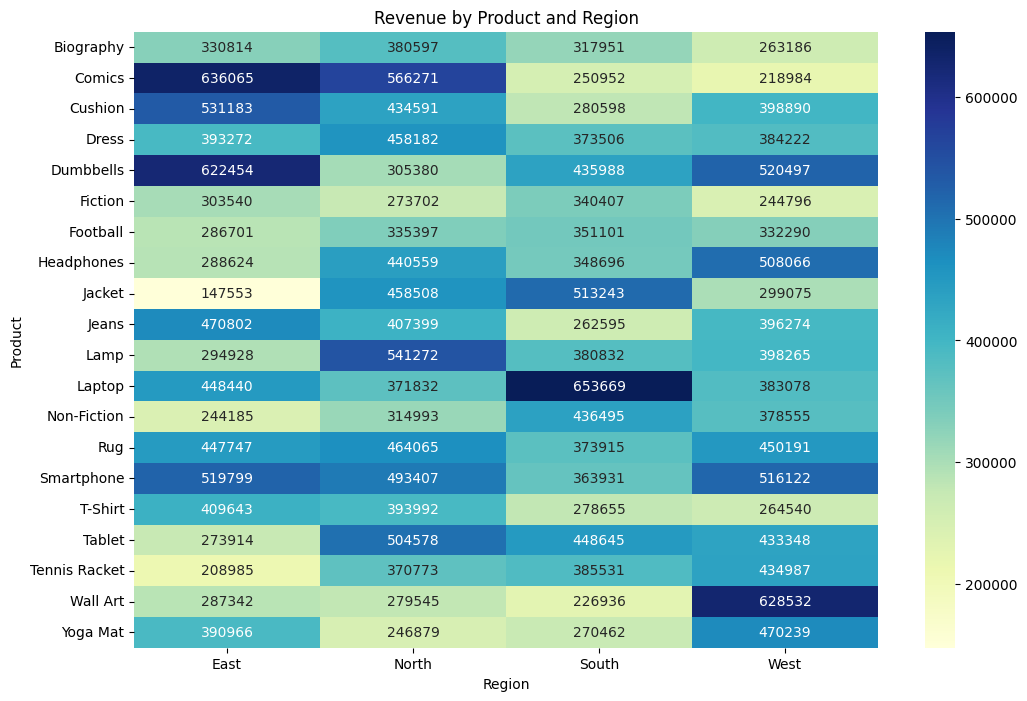

In [16]:
#Heatmap: Product vs Region

def plot_heatmap_data():
    heatmap_data = df.pivot_table(index='Product', columns='Region', values='Revenue', aggfunc='sum', fill_value=0)
    plt.figure(figsize=(12, 8))
    sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlGnBu')
    plt.title('Revenue by Product and Region')
    plt.show()
    plt.show(block=False)
    plt.pause(0.001)

plot_heatmap_data()

### **Heatmap** titled **“Revenue by Product and Region”**

It gives us a clear and colorful way to analyze how different products perform across different regions.

---

* **Rows**: Different products (e.g., Comics, Laptop, Yoga Mat, etc.)
* **Columns**: Regions (East, North, South, West)
* **Cell Color**: Represents revenue (lighter = lower, darker = higher)
* **Cell Value**: Actual revenue amount for that product in that region

---

#### Key Observations:

#### 1. **Laptop is a superstar in the South**

* Revenue: ₹6,53,669 — the **darkest blue** in the whole chart.
* Clearly, **Laptops are in high demand** in the South.

#### 2. **Wall Art is extremely strong in the West**

* Revenue: ₹6,28,532 — another deep blue.
* West region may have a strong decor or lifestyle segment.

#### 3. **Comics dominate in East and North**

* Revenue in East: ₹6,36,065
* Revenue in North: ₹5,66,271
* Strong popularity — possibly due to younger demographics or targeted campaigns.

#### 4. **Smartphone and Dumbbells are consistent performers**

* They show **strong revenues across multiple regions**, not just one.
* Smartphones are especially high in West (₹5,16,122) and East (₹5,19,799).
* Dumbbells also perform well in East and West.

#### 5. **Weak segments:**

* Products like **Tennis Racket, Fiction, and Biography** show lighter shades across most regions.
* These may be **low-priority or niche** segments.

---

#### Actionable Insights

| Observation                                                  | Business Action                                                                                 |
| ------------------------------------------------------------ | ----------------------------------------------------------------------------------------------- |
| **Laptop sales strong in South**                          | Focus inventory, promotions, and after-sales support there. Consider bundling with accessories. |
| **Wall Art booming in West**                              | Expand this product line in the West — push premium or festive collections.                     |
| **Comics thriving in East and North**                     | Consider offering subscriptions, collector editions, or launching more titles.                  |
| **Smartphone and Dumbbells perform well everywhere**    | Treat them as **core products**. Ensure constant stock and seasonal discounts.                  |
| **Low-performing items like Tennis Racket and Biography** | Review if they need better marketing or if they should be phased out or repositioned.           |


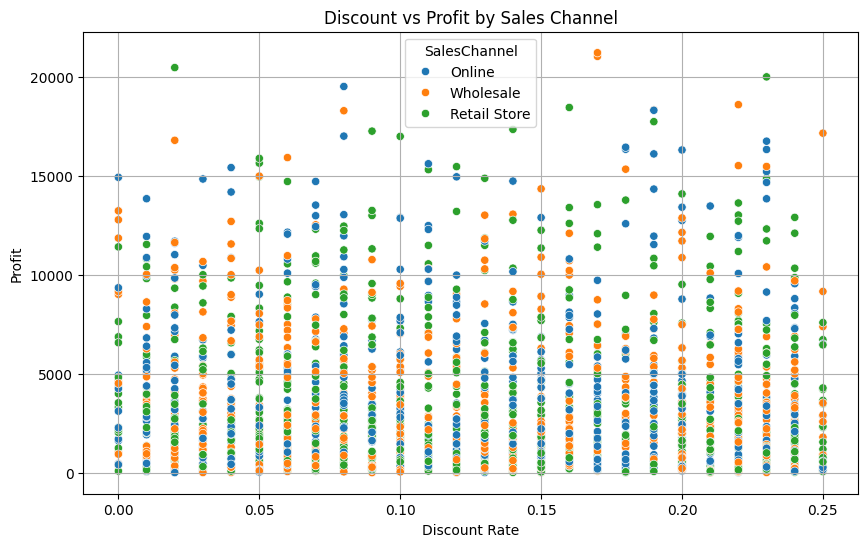

In [17]:
# Discount Impact on Profit
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="Discount", y="Profit", hue="SalesChannel")
plt.title("Discount vs Profit by Sales Channel")
plt.xlabel("Discount Rate")
plt.ylabel("Profit")
plt.grid()
plt.show()

### **Scatter plot - “Discount vs Profit by Sales Channel”**

This is a powerful chart that helps us understand how discounting affects profit across different sales channels.

---


* **X-axis**: Discount Rate (from 0% to 25%)
* **Y-axis**: Profit (₹0 to ₹20,000+)
* **Each dot**: A transaction or record
* **Color of dots**: Represents **Sales Channel**

---

#### Key Observations

### 1. **Higher Profits Still Happen at Lower Discounts**

* Many of the **highest profit points** occur when **discount is low (0–10%)**.
* Suggests that big discounts aren’t necessary to achieve high profits.

### 2. **Heavy Discounting (>15%) Doesn’t Guarantee Higher Profit**

* From 15%–25% discount, profit points **scatter and flatten** out.
* Indicates **diminishing returns** — increasing discount does **not lead to higher profit**.

### 3. **Online Channel Shows Consistent Profitability**

* Blue dots are **more concentrated above the ₹10,000 mark**.
* Online seems to maintain profit better across discount ranges.

### 4. **Wholesale Appears More Spread Out**

* Orange dots have more **variation** — some very low, some high.
* Suggests less predictable outcomes in the Wholesale channel.

### 5. **Retail Store is Stable in Mid-Profit Range**

* Green dots show more **mid-level profits** regardless of discount rate.
* Possibly indicates **stronger in-person conversion but smaller per-unit profit**.

---

#### Actionable Insights for Business

| Insight                                                        | Action                                                                                  |
| -------------------------------------------------------------- | --------------------------------------------------------------------------------------- |
| High discounts (>15%) don’t lead to better profits          | Limit discounts beyond 15% unless it’s a clearance or special event                   |
| Online sales generate strong profit even at lower discounts | Invest in the online channel with value-focused marketing (not just discount-driven) |
| Wholesale has inconsistent performance                      | Review B2B pricing or customer segmentation strategy                                 |
| Retail is predictable but not very high                     | Explore upselling/cross-selling or premium product placements in stores              |
| Sweet spot appears at 5–10% discount                        | A/B test promotions in this range to optimize both volume and profit                 |

---
---

### Function to analyze how different **customer segments** perform in terms of revenue and profit.

The function

* Helps you understand **which customer segments are most valuable**.
* Supports marketing and sales strategies — e.g., reward loyal customers, attract more high-value new ones.
---

#### `def plot_segment_analysis():`

* `def` is short for **define** — it tells Python we’re creating a function.
* `plot_segment_analysis` is the name of the function. It describes what this function will do: **plot analysis for each segment**.
* The `():` means we aren’t passing anything into the function right now.
* The colon `:` means everything indented below this line is **part of the function**.

---

#### `segment_analysis = df.groupby("Segment")[["Revenue", "Profit"]].sum().sort_values("Revenue", ascending=False)`

This line prepares the data for plotting. Let’s break it into parts:

#### `df.groupby("Segment")`

* This takes your whole DataFrame and **groups the rows** based on the **Segment** column.
* Example: Segments like `"Regular"`, `"Loyal"`, `"New"`, `"Returning"` get grouped together.

#### `[["Revenue", "Profit"]]`

* After grouping, we focus only on the **Revenue** and **Profit** columns.
* We're ignoring other columns like Date, Product, etc.

#### `.sum()`

* Adds up all the revenue and profit **within each segment**.
* Now we know total revenue and profit for each type of customer.

#### `.sort_values("Revenue", ascending=False)`

* This sorts the segments by their total revenue from **highest to lowest**.

At the end of this line, we have a summary table showing each segment’s total Revenue and Profit, sorted from best to worst by Revenue.

---

#### `segment_analysis.plot(kind="bar", figsize=(8,5), title="Segment-wise Revenue & Profit")`

Now we’re ready to draw the chart:

* `.plot(...)` creates the actual bar chart.
* `kind="bar"` tells Python to make **vertical bars**.
* `figsize=(8,5)` sets the size of the chart (8 inches wide, 5 inches tall).
* `title="Segment-wise Revenue & Profit"` puts a title on top of the chart.

Each segment will have **two bars** next to each other: one for Revenue, one for Profit.

---

#### `plot_segment_analysis()`

This is where we **call** the function — like pressing the “Run” button on the recipe.

* This line tells Python:

> “Now go and execute the function we defined above.”

And it will do all the steps: group the data, calculate sums, sort, and then plot the chart.

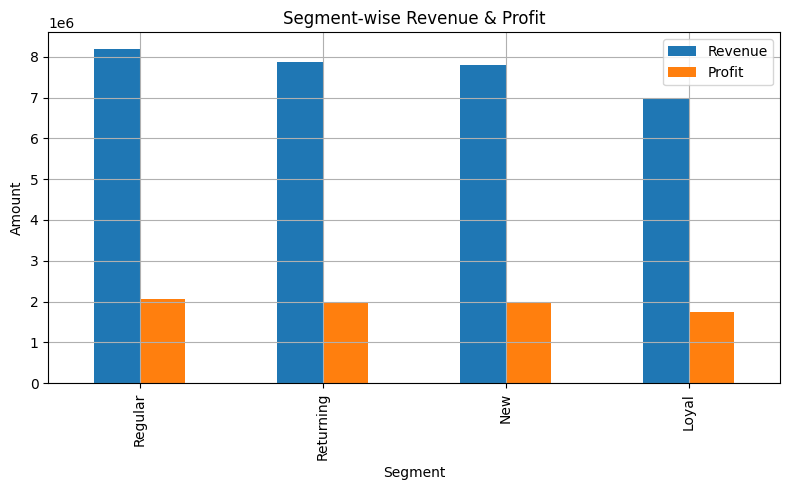

In [18]:
def plot_segment_analysis():
    segment_analysis = df.groupby("Segment")[["Revenue", "Profit"]].sum().sort_values("Revenue",
                                                                              ascending=False)
    segment_analysis.plot(kind="bar", figsize=(8,5), title="Segment-wise Revenue & Profit")
    plt.ylabel("Amount")
    plt.grid()
    plt.tight_layout()
    plt.show()
    plt.show(block=False)
    plt.pause(0.001)

plot_segment_analysis()

### Interpret the **bar chart** - **"Segment-wise Revenue & Profit"**

---

* **X-axis**: Four customer segments:

  * Regular
  * Returning
  * New
  * Loyal

* **Y-axis**: Amount in revenue and profit (scale is up to ₹8 million)

* **Two bars per segment**:

  * **Revenue** (in blue)
  * **Profit** (in orange)

---

#### Key Observations:

#### 1. **Regular Customers Generate the Highest Revenue**

* Revenue is above ₹8 million — the tallest bar.
* This segment likely has consistent buying behavior over time.

#### 2. **Returning and New Customers Are Close Behind**

* Revenue from these two segments is slightly below Regular.
* Indicates good engagement with first-time and repeat buyers.

#### 3. **Loyal Segment Has the Lowest Revenue and Profit**

* Surprisingly, the "Loyal" segment generates **less revenue and less profit** compared to others.
* This may suggest they receive higher discounts or buy less frequently.

#### 4. **Profit Trends Follow Revenue, But Are Not Identical**

* All segments generate over ₹1.7 million in profit.
* However, **differences in margins or discounts** might be at play.

---

#### Actionable Business Insights

| Observation                                       | Recommended Action                                                                                                       |
| ------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------ |
| Regular customers are the top contributors     | Focus retention strategies (e.g., personalized offers, priority support) to keep them buying                           |
| New and Returning segments are performing well | Target them with welcome offers, re-engagement emails, and seasonal deals                                             |
| Loyal segment underperforms                     | Investigate why — are we giving too much discount? Is product relevance declining? Consider a loyalty program refresh |
| Profit consistency across segments             | Explore if some segments are **more profitable per unit** — this can optimize ad spend targeting                      |
| No segment is drastically failing              | Good overall balance — now focus on **deepening value per customer** rather than only acquiring more                   |

---
---

### Calculate the **monthly revenue** and create a **3-month moving average** to smooth out short-term fluctuations and identify trends.

* Calculates **total revenue for each month**
* Converts month into a clean string format
* Adds a **3-month moving average** column to see overall revenue trends more clearly

---

#### `monthly_revenue = df.groupby("Month")["Revenue"].sum().reset_index()`


#### `df.groupby("Month")`

* This groups your full dataset by the `"Month"` column.
* For example, all rows from **January 2022** are grouped together, all from **February 2022** together, and so on.

#### `["Revenue"]`

* After grouping, we are only interested in the `"Revenue"` column.

#### `.sum()`

* We add up all the revenue values within each month group.
* So, now we have **total revenue for each month**.

#### `.reset_index()`

* This turns the groupby result back into a regular DataFrame so it can be used easily.
* Without this, the "Month" would still be stuck as an index.

At the end of this line, `monthly_revenue` is a table with two columns:
`Month` and `Revenue`.

---

#### `monthly_revenue["Month"] = monthly_revenue["Month"].astype(str)`

This line converts the **Month column values to string format**.

* `astype(str)` changes the data type from something like a date period (e.g., `Period('2022-01', 'M')`) to a simple string like `"2022-01"`.
* This is useful if we want to **display months clearly on a chart** or use them in labels.

---

#### `monthly_revenue["Revenue_MA3"] = monthly_revenue["Revenue"].rolling(3).mean()`

This line calculates the **3-month moving average** for revenue.

#### `monthly_revenue["Revenue"]`

* This picks the Revenue column.

#### `.rolling(3)`

* This creates a sliding window of size 3 over the Revenue values.
* It looks at the current month and the **2 months before it**.

#### `.mean()`

* It calculates the **average revenue** for that 3-month window.

The result is a **new column** called `"Revenue_MA3"` which shows the **smoothed trend** in revenue.

This helps to:

* Reduce noise from random spikes
* Highlight the actual direction of the business over time


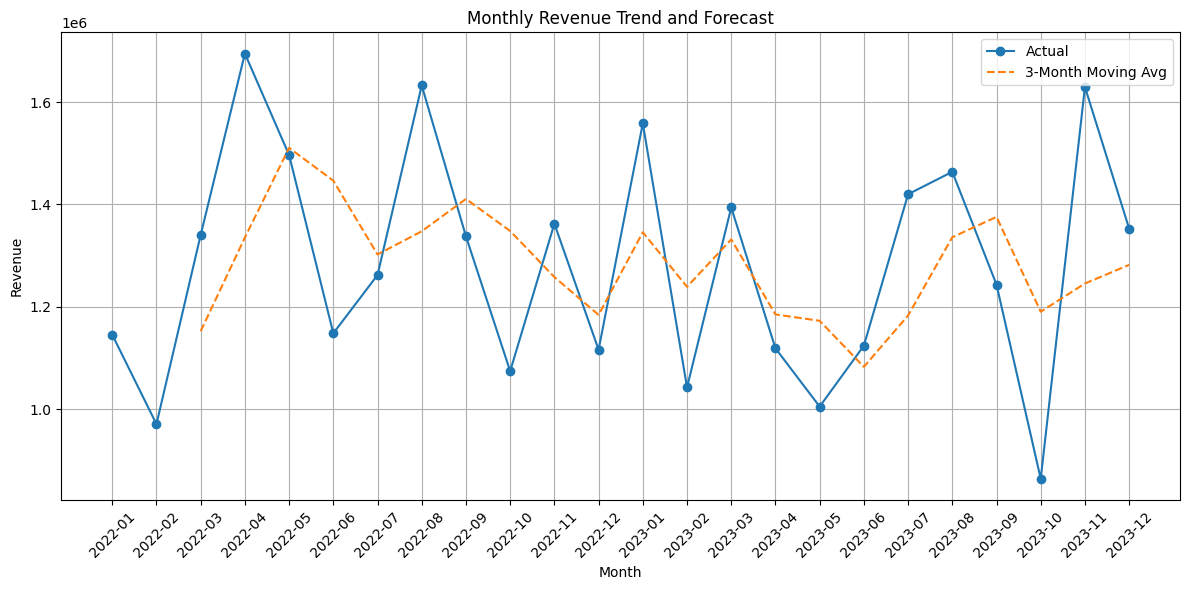

In [19]:
def plot_monthly_revenue():
    monthly_revenue = df.groupby("Month")["Revenue"].sum().reset_index()
    monthly_revenue["Month"] = monthly_revenue["Month"].astype(str)
    monthly_revenue["Revenue_MA3"] = monthly_revenue["Revenue"].rolling(3).mean()

    plt.figure(figsize=(12,6))
    plt.plot(monthly_revenue["Month"], monthly_revenue["Revenue"], label="Actual", marker='o')
    plt.plot(monthly_revenue["Month"], monthly_revenue["Revenue_MA3"], label="3-Month Moving Avg",
            linestyle='--')
    plt.xticks(rotation=45)
    plt.title("Monthly Revenue Trend and Forecast")
    plt.xlabel("Month")
    plt.ylabel("Revenue")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()
    plt.show(block=False)
    plt.pause(0.001)

plot_monthly_revenue()

### **Line chart - "Monthly Revenue Trend and Forecast"**

---

* **X-axis**: Time — monthly periods from January 2022 to December 2023.
* **Y-axis**: Revenue — how much was earned each month.
* **Blue Line (Actual)**: The true revenue for each month.
* **Orange Dashed Line (3-Month Moving Avg)**: A smoothed version of the revenue that shows trends by averaging each month with the two before it.

---

#### Key Observations

#### 1. **Revenue is Highly Volatile Month to Month**

* The actual (blue) line has many **sharp peaks and valleys**.
* Some months like **April 2022 and November 2023** show **spikes**, while others like **October 2023** show deep drops.
* Business activity likely fluctuates due to **seasonality**, promotions, or campaigns.

#### 2. **3-Month Moving Average is Much Smoother**

* The orange dashed line filters out the “noise”.
* It shows a more **stable view of the trend** over time.
* It’s a good way to predict near-term future performance.

#### 3. **Revenue Recovery After Dips**

* After big drops (e.g., October 2023), there’s often a rebound (e.g., November 2023).
* This suggests possible **seasonal cycles** — maybe Diwali, Black Friday, or Year-End boosts?

#### 4. **No Strong Upward or Downward Trend Overall**

* While there are fluctuations, the moving average hovers mostly between **₹1.2M and ₹1.4M**.
* This may indicate a **steady business**, but without major growth.

---

#### Actionable Business Insights

| Observation                                 | Recommended Action                                                                          |
| ------------------------------------------- | ------------------------------------------------------------------------------------------- |
| Volatile monthly revenue                 | Investigate what’s causing spikes and drops — marketing campaigns, festivals, stockouts? |
| Spikes in April, August, November        | Consider aligning **campaigns, product launches, or stock planning** with these months   |
| Big dip in October 2023                  | Review October's pricing, stock, ad budget, or website issues — prevent repeat           |
| Moving average is stable                 | Indicates a **reliable core business** — now focus on **expansion or margin improvement** |
| 3-Month moving average helps forecasting | Use this for **demand planning**, inventory decisions, and goal setting                  |


    1. View Monthly Revenue and Profit Trends
    2. View Revenue by Category
    3. View Top 5 Products by Profit
    4. View Revenue by Product and Region
    5. View Sales Channel Performance
    6. View Segment-wise Revenue & Profit
    7. View Monthly Revenue Trend and Forecast
    0. Exit
    
>>> Enter your choice (0-7): 1


,Month,Revenue,Profit
0,2022-01,1145474.10,302302.35
1,2022-02,970731.15,246663.10
2,2022-03,1340438.81,367844.20
3,2022-04,1694780.50,425758.01
4,2022-05,1496537.10,381685.97
5,2022-06,1148224.59,273797.17
6,2022-07,1262042.57,306479.18
7,2022-08,1632459.73,420655.04
8,2022-09,1337702.62,342510.25
9,2022-10,1074222.31,243886.24



    1. View Monthly Revenue and Profit Trends
    2. View Revenue by Category
    3. View Top 5 Products by Profit
    4. View Revenue by Product and Region
    5. View Sales Channel Performance
    6. View Segment-wise Revenue & Profit
    7. View Monthly Revenue Trend and Forecast
    0. Exit
    
>>> Enter your choice (0-7): 2


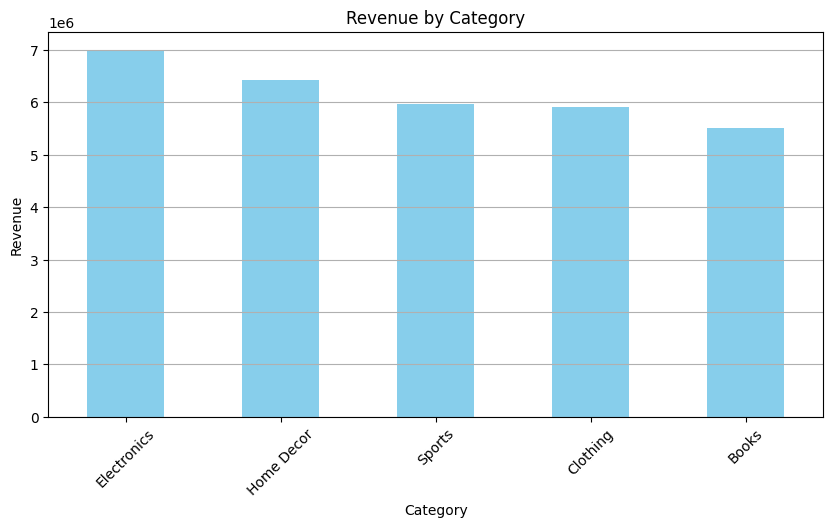


    1. View Monthly Revenue and Profit Trends
    2. View Revenue by Category
    3. View Top 5 Products by Profit
    4. View Revenue by Product and Region
    5. View Sales Channel Performance
    6. View Segment-wise Revenue & Profit
    7. View Monthly Revenue Trend and Forecast
    0. Exit
    
>>> Enter your choice (0-7): 3


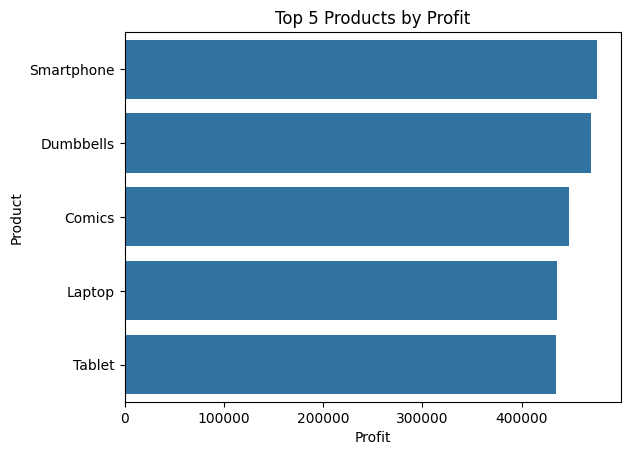


    1. View Monthly Revenue and Profit Trends
    2. View Revenue by Category
    3. View Top 5 Products by Profit
    4. View Revenue by Product and Region
    5. View Sales Channel Performance
    6. View Segment-wise Revenue & Profit
    7. View Monthly Revenue Trend and Forecast
    0. Exit
    
>>> Enter your choice (0-7): 0
Exiting summary viewer.


In [23]:
# CLI-like user interaction: View summary options
def show_summary():
    print("""
    1. View Monthly Revenue and Profit Trends
    2. View Revenue by Category
    3. View Top 5 Products by Profit
    4. View Revenue by Product and Region
    5. View Sales Channel Performance
    6. View Segment-wise Revenue & Profit
    7. View Monthly Revenue Trend and Forecast
    0. Exit
    """)

while True:
    show_summary()
    choice = input(">>> Enter your choice (0-7): ")
    if choice == '1':
        display(monthly_trend)
    elif choice == '2':
        plot_cat_rev()
    elif choice == '3':
        plot_top_products()
    elif choice == '4':
        plot_heatmap_data()
    elif choice == '5':
        plot_channel_perf()
    elif choice == '6':
        plot_segment_analysis()
    elif choice == '7':
        plot_monthly_revenue()
    elif choice == '0':
        print("Exiting summary viewer.")
        break
    else:
        print("Invalid option. Please try again.")